# Task 3: Unsupervised Learning — K-Means Clustering

**Research question:** Can hourly weather observations in Hanoi - including temperature, humidity, wind speed,
atmospheric pressure - be clustered into distinct groups, and do these groups correspond to
patterns in air quality warnings?

## 3.1 Install & Import Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

# Reproducibility
RANDOM_STATE = 42
K_RANGE = range(2, 11)

# Helper: silhouette plot
def plot_silhouette(X, labels, k, ax):
    sil_vals = silhouette_samples(X, labels)
    avg = sil_vals.mean()
    colors = plt.cm.tab10.colors
    y_lower = 10
    for i in range(k):
        cluster_vals = np.sort(sil_vals[labels == i])
        size = cluster_vals.shape[0]
        y_upper = y_lower + size
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                         facecolor=colors[i % 10], alpha=0.85)
        ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=9)
        y_lower = y_upper + 10
    ax.axvline(x=avg, color="red", linestyle="--", linewidth=1.2,
               label=f"avg = {avg:.3f}")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")
    ax.legend(fontsize=9)

## 3.2 Load Dataset & Preprocessing

In [37]:
df = pd.read_csv('data/hanoi_air_quality_clean.csv', parse_dates=['timestamp'])

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["timestamp"].min()} → {df["timestamp"].max()}')
print(f'\nColumns: {list(df.columns)}')
df.head()

Dataset shape: (8760, 14)
Date range: 2025-01-01 00:00:00 → 2025-12-31 23:00:00

Columns: ['timestamp', 'temperature', 'humidity', 'wind_speed', 'pressure', 'hour', 'day_of_week', 'is_weekend', 'wind_direction', 'precipitation', 'cloud_cover', 'is_warning', 'aqi', 'pm25']


,timestamp,temperature,humidity,wind_speed,pressure,hour,day_of_week,is_weekend,wind_direction,precipitation,cloud_cover,is_warning,aqi,pm25
0,2025-01-01 00:00:00,14.1,91,1.138889,1016.6,0,2,0,319,0.0,0,1,158,111.3
1,2025-01-01 01:00:00,13.5,93,1.277778,1016.6,1,2,0,321,0.0,4,1,159,112.7
2,2025-01-01 02:00:00,12.9,94,1.083333,1016.1,2,2,0,317,0.0,0,1,160,113.2
3,2025-01-01 03:00:00,12.6,96,1.277778,1015.5,3,2,0,315,0.0,0,1,162,113.9
4,2025-01-01 04:00:00,12.4,96,1.277778,1015.4,4,2,0,312,0.0,2,1,163,115.5


In [38]:
# Cyclical encoding for hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df = df.drop(columns=['hour'])

print('Feature engineering complete.')
print(f'Columns now: {list(df.columns)}')

Feature engineering complete.
Columns now: ['timestamp', 'temperature', 'humidity', 'wind_speed', 'pressure', 'day_of_week', 'is_weekend', 'wind_direction', 'precipitation', 'cloud_cover', 'is_warning', 'aqi', 'pm25', 'hour_sin', 'hour_cos']


In [39]:
# Standard scaling on continuous features
cols_to_scale = ['temperature', 'humidity', 'wind_speed', 'pressure', 'precipitation', 'cloud_cover']

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print('Scaling complete. Sample statistics (should be mean≈0, std≈1):')
print(df_scaled[cols_to_scale].describe().round(3))

Scaling complete. Sample statistics (should be mean≈0, std≈1):
       temperature  humidity  wind_speed  pressure  precipitation  cloud_cover
count     8760.000  8760.000    8760.000  8760.000       8760.000     8760.000
mean         0.000     0.000      -0.000    -0.000          0.000        0.000
std          1.000     1.000       1.000     1.000          1.000        1.000
min         -3.084    -3.593      -1.851    -3.009         -0.241       -1.989
25%         -0.723    -0.633      -0.761    -0.791         -0.241       -0.763
50%          0.150     0.175      -0.098    -0.047         -0.241        0.676
75%          0.708     0.847       0.628     0.803         -0.153        0.676
max          2.585     1.386       5.502     3.047         25.125        0.676


## 3.3 Feature Sets

We compare two feature configurations to find the most informative one:

| Version | Features | Rationale |
|---|---|---|
| **V2** — Weather Only | `temperature`, `humidity`, `wind_speed`, `pressure` | Core meteorological drivers of air quality |
| **V3** — Weather + Time | Above + `hour_sin`, `hour_cos` | Adds diurnal pattern (rush-hour, overnight trapping) |

The binary target `is_warning`, `aqi`, and `pm25` are **excluded** from clustering and used only for post-hoc interpretation.

In [40]:
FEATURES_V2 = ['temperature', 'humidity', 'wind_speed', 'pressure']
FEATURES_V3 = ['temperature', 'humidity', 'wind_speed', 'pressure', 'hour_sin', 'hour_cos']

X_v2 = df_scaled[FEATURES_V2]
X_v3 = df_scaled[FEATURES_V3]

print(f'V2 shape: {X_v2.shape}  ({len(FEATURES_V2)} features)')
print(f'V3 shape: {X_v3.shape}  ({len(FEATURES_V3)} features)')

V2 shape: (8760, 4)  (4 features)
V3 shape: (8760, 6)  (6 features)


## 3.4 Choosing the Number of Clusters (K)

We use two complementary methods across K = 2…10:
- **Elbow Method** (inertia): look for the point where additional clusters give diminishing returns
- **Silhouette Score**: higher = tighter, better-separated clusters

In [41]:
def evaluate_k_range(X, df, label):
    """Run KMeans for K=2..10 and return inertia, silhouette lists and warining rate change."""
    inertias, silhouettes = [], []
    print(f'\n{"─"*75}')
    print(f'  {label}')
    print(f'  {"K":>3}   {"Inertia":>12}   {"Silhouette":>10}   {"Min WR%":>8}   {"Max WR%":>8}   {"Range":>8}')
    print(f'{"─"*75}')
    for k in K_RANGE:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        km.fit(X)
        sil = silhouette_score(X, km.labels_)
        inertias.append(km.inertia_)
        silhouettes.append(sil)
        rates = df.groupby(km.labels_)['is_warning'].mean().mul(100)
        wr_min, wr_max = rates.min(), rates.max()
        wr_range = wr_max - wr_min
        print(f'  {k:>3}   {km.inertia_:>12,.1f}   {sil:>10.4f}   '
              f'{wr_min:>7.2f}%   {wr_max:>7.2f}%   {wr_range:>7.2f}%')
    return inertias, silhouettes

inertias_v2, silhouettes_v2 = evaluate_k_range(X_v2, df, 'V2: Weather Only (4 features)')
inertias_v3, silhouettes_v3 = evaluate_k_range(X_v3, df, 'V3: Weather + Time (6 features)')


───────────────────────────────────────────────────────────────────────────
  V2: Weather Only (4 features)
    K        Inertia   Silhouette    Min WR%    Max WR%      Range
───────────────────────────────────────────────────────────────────────────
    2       22,451.9       0.3395     70.19%     81.21%     11.02%
    3       18,545.5       0.2588     67.24%     82.40%     15.16%
    4       15,224.6       0.2634     61.11%     83.40%     22.29%
    5       12,929.4       0.2769     61.52%     88.50%     26.98%
    6       11,444.8       0.2803     40.10%     88.62%     48.52%
    7       10,469.0       0.2761     34.60%     88.70%     54.10%
    8        9,695.7       0.2588     38.18%     88.47%     50.30%
    9        9,111.8       0.2461     35.78%     88.67%     52.90%
   10        8,598.7       0.2465     33.52%     88.59%     55.08%

───────────────────────────────────────────────────────────────────────────
  V3: Weather + Time (6 features)
    K        Inertia   Silhouette 

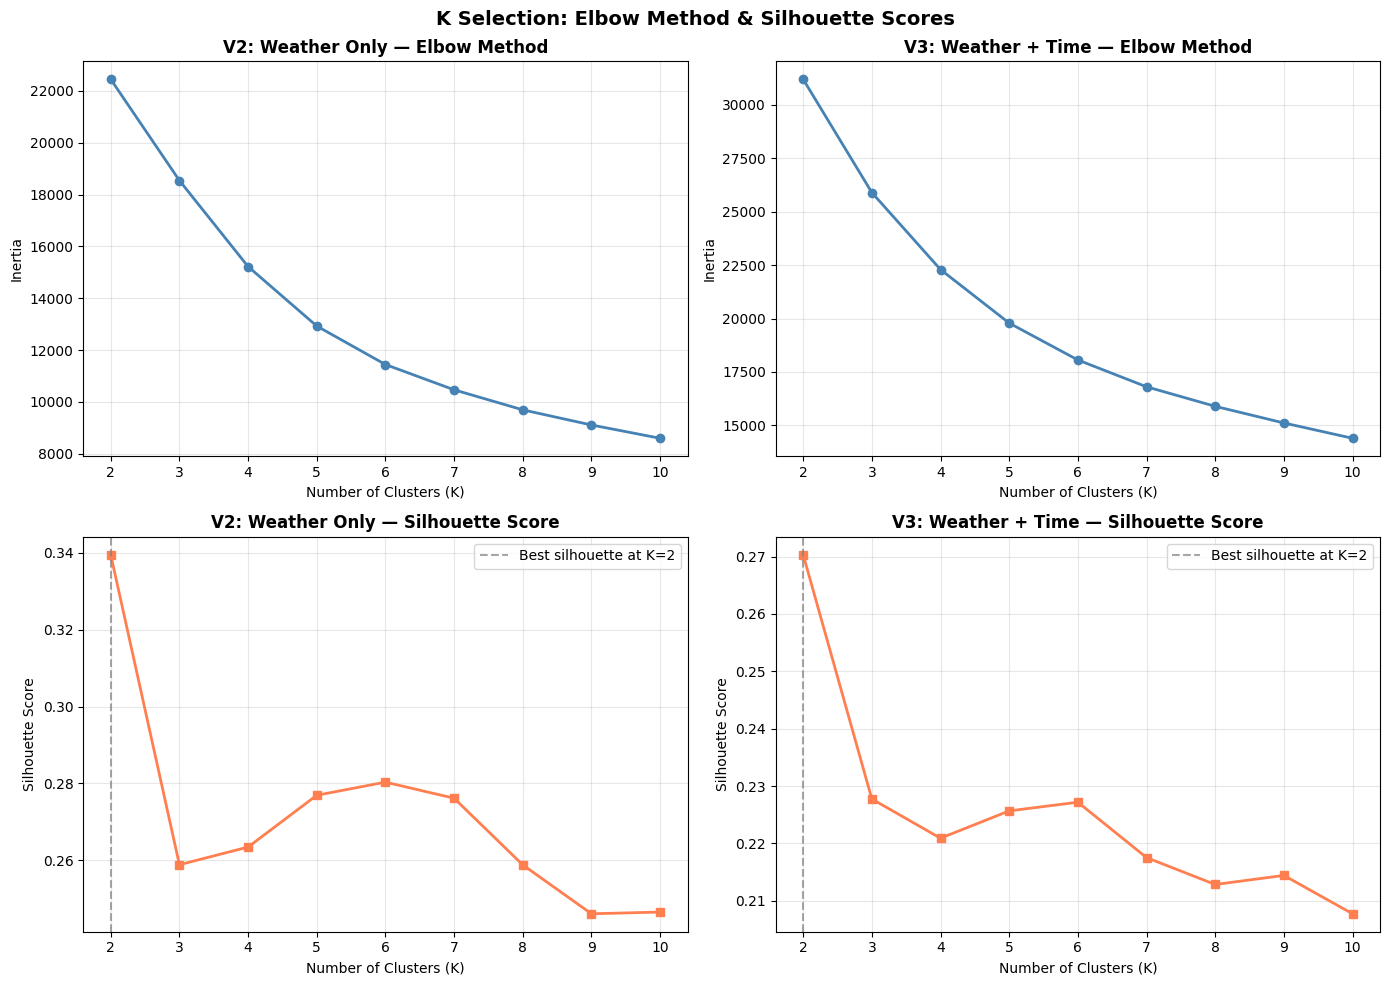

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('K Selection: Elbow Method & Silhouette Scores', fontsize=14, fontweight='bold')

k_list = list(K_RANGE)

for col, (label, inertias, silhouettes) in enumerate([
    ('V2: Weather Only', inertias_v2, silhouettes_v2),
    ('V3: Weather + Time', inertias_v3, silhouettes_v3)
]):
    # Elbow
    ax = axes[0, col]
    ax.plot(k_list, inertias, marker='o', color='steelblue', linewidth=2)
    ax.set_title(f'{label} — Elbow Method', fontweight='bold')
    ax.set_xlabel('Number of Clusters (K)')
    ax.set_ylabel('Inertia')
    ax.grid(True, alpha=0.3)

    # Silhouette
    ax = axes[1, col]
    ax.plot(k_list, silhouettes, marker='s', color='coral', linewidth=2)
    best_k_idx = int(np.argmax(silhouettes))
    ax.axvline(x=k_list[best_k_idx], color='gray', linestyle='--', alpha=0.7,
               label=f'Best silhouette at K={k_list[best_k_idx]}')
    ax.set_title(f'{label} — Silhouette Score', fontweight='bold')
    ax.set_xlabel('Number of Clusters (K)')
    ax.set_ylabel('Silhouette Score')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("visuals/task3_k_selection_elbow_silhouette.png", dpi=300, bbox_inches="tight")
plt.show()

We evaluate K = 3, 4, 5, 6 using a multi-resolution approach, each justified independently.

**K = 3 — Elbow baseline.** The steepest inertia drop occurs at K = 3 (V2: 22,452 → 18,546; V3: 31,204 → 25,900), capturing the most fundamental structure with the fewest clusters. The three clusters correspond to three broad weather regimes with meaningfully different warning rates (67%, 81%, 82%). Serves as a comparison baseline — without K = 3, it is difficult to quantify what each larger K adds incrementally.

**K = 4 — Domain reasoning and warning rate improvement.** Four clusters align naturally with Hanoi's four seasons, making results directly interpretable in a real-world context. Statistically, moving from K = 3 → 4 produces meaningful improvement: minimum warning rate drops from 67% to 61%, range widens from 15% to 22%, and silhouette improves (0.2588 → 0.2634). This confirms the fourth cluster captures a genuinely distinct weather condition rather than an arbitrary split. PCA visualization also remains relatively clear at K = 4.

**K = 5 — Best statistical balance.** Outperforms K = 4 on every quantitative metric: silhouette increases to 0.2769 and warning rate range widens to 27%. A new hot-windy cluster emerges (temp ~31°C, wind ~4.09, WR 68%) — notably lower than other high-temperature clusters — revealing that strong wind disperses pollutants even under hot conditions, a physically meaningful insight not visible at K = 3 or 4. Limitation: PCA visualization shows more overlap compared to K = 4.

**K = 6 — Best risk separation.** Warning rate range jumps from 27% to 48% — the largest single increase across the entire K = 2–10 range. Most importantly, a distinct low-risk cluster emerges for the first time: cool-windy conditions (temp ~18°C, wind ~3.89, WR 40%), with direct practical value for air quality forecasting. Silhouette also peaks at 0.2803 for V2, the highest in the K = 3–10 range. Limitation: more PCA overlap, partly attributable to PCA retaining only 75.9% of variance — silhouette on the original 4D space remains the more reliable indicator.

| K | Primary Justification | Limitation |
|---|---|---|
| 3 | Elbow point; comparison baseline | Lowest warning range (15%) |
| 4 | 4-season domain reasoning; warning range 15% → 22%, silhouette improves | Weaker for V3 |
| 5 | Best silhouette and warning range among K = 3–5 | More PCA overlap than K = 4 |
| 6 | Silhouette peak (0.2803); isolates low-risk cluster (WR 40%); range jumps to 48% | PCA overlap; small cluster drives range |

## 3.5 K Candidate Evaluation (K = 3, 4, 5, 6)


In [43]:
K_COMPARE = [3, 4, 5, 6]

def fit_kmeans_dict(X, k_list):
    """Fit KMeans for each K in k_list. Returns {k: fitted_model}."""
    models = {}
    for k in k_list:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        km.fit(X)
        models[k] = km
    return models

models_v2 = fit_kmeans_dict(X_v2, K_COMPARE)
models_v3 = fit_kmeans_dict(X_v3, K_COMPARE)

# Quick metrics overview
print(f'  {"":20} {"V2 (Weather Only)":>38} {"V3 (Weather + Time)":>38}')
print(f'  {"K":>3}   {"Inertia":>12}  {"Silhouette":>10}  {"Min WR%":>8}  {"Range":>7}    {"Inertia":>12}  {"Silhouette":>10}  {"Min WR%":>8}  {"Range":>7}')
print('  ' + '─'*105)
for k in K_COMPARE:
    s2 = silhouette_score(X_v2, models_v2[k].labels_)
    s3 = silhouette_score(X_v3, models_v3[k].labels_)
    r2 = df.groupby(models_v2[k].labels_)['is_warning'].mean().mul(100)
    r3 = df.groupby(models_v3[k].labels_)['is_warning'].mean().mul(100)
    print(f'  {k:>3}   {models_v2[k].inertia_:>12,.1f}  {s2:>10.4f}  {r2.min():>7.2f}%  {r2.max()-r2.min():>6.2f}%    '
          f'{models_v3[k].inertia_:>12,.1f}  {s3:>10.4f}  {r3.min():>7.2f}%  {r3.max()-r3.min():>6.2f}%')

                                            V2 (Weather Only)                    V3 (Weather + Time)
    K        Inertia  Silhouette   Min WR%    Range         Inertia  Silhouette   Min WR%    Range
  ─────────────────────────────────────────────────────────────────────────────────────────────────────────
    3       18,545.5      0.2588    67.24%   15.16%        25,900.2      0.2277    64.03%   18.62%
    4       15,224.6      0.2634    61.11%   22.29%        22,295.4      0.2209    63.52%   18.06%
    5       12,929.4      0.2769    61.52%   26.98%        19,789.3      0.2257    64.62%   22.07%
    6       11,444.8      0.2803    40.10%   48.52%        18,062.8      0.2272    39.81%   47.74%


In [44]:
K_COMPARE = [3, 4, 5, 6]

def cluster_profile(X, df, k, version_label):
    """Fit KMeans and return detailed cluster profile."""
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)

    profile = df.groupby(labels)[['temperature', 'humidity', 'wind_speed', 'pressure']].mean().round(2)
    profile['count'] = df.groupby(labels)['is_warning'].count().values
    profile['pct%'] = (profile['count'] / len(df) * 100).round(1)
    profile['warning_rate%'] = df.groupby(labels)['is_warning'].mean().mul(100).round(2)

    print(f'\n{"─"*70}')
    print(f'  {version_label} | K = {k}')
    print(f'{"─"*70}')
    print(profile.to_string())
    return labels, km

for k in K_COMPARE:
    cluster_profile(X_v2, df, k, 'V2: Weather Only')

for k in K_COMPARE:
    cluster_profile(X_v3, df, k, 'V3: Weather + Time')


──────────────────────────────────────────────────────────────────────
  V2: Weather Only | K = 3
──────────────────────────────────────────────────────────────────────
   temperature  humidity  wind_speed  pressure  count  pct%  warning_rate%
0        18.66     70.00        2.40   1017.28   3074  35.1          67.24
1        24.71     91.89        1.78   1006.42   3120  35.6          82.40
2        29.16     75.48        3.17   1002.75   2566  29.3          80.71

──────────────────────────────────────────────────────────────────────
  V2: Weather Only | K = 4
──────────────────────────────────────────────────────────────────────
   temperature  humidity  wind_speed  pressure  count  pct%  warning_rate%
0        19.95     58.38        2.82   1017.58   1643  18.8          61.11
1        26.56     89.45        1.67   1004.54   2855  32.6          83.40
2        18.05     85.62        1.93   1015.52   2047  23.4          78.11
3        28.78     76.30        3.48   1002.98   2215  25.3 

### 3.5.1 V2: Weather Only — Silhouette (K = 3, 4, 5, 6)

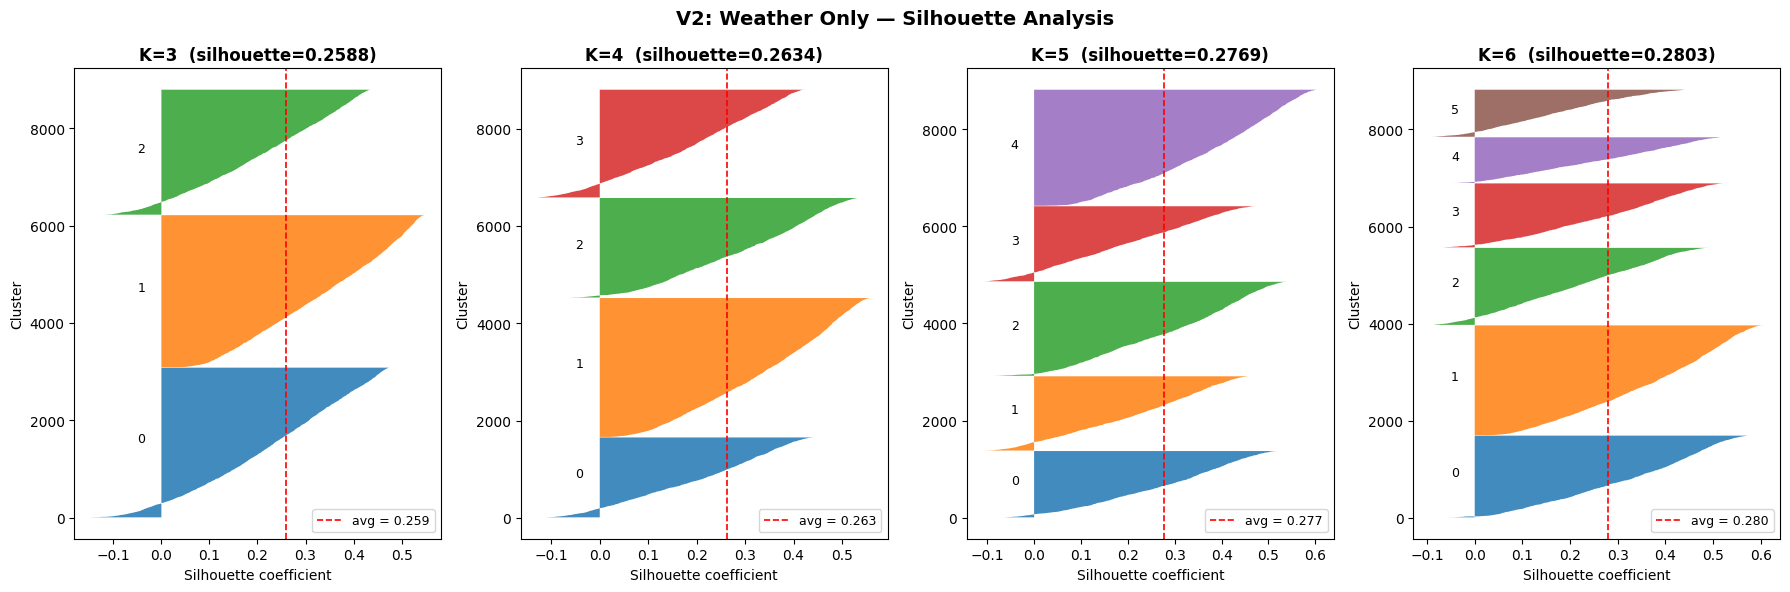

In [45]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle('V2: Weather Only — Silhouette Analysis', fontsize=14, fontweight='bold')

for ax, k in zip(axes, K_COMPARE):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_v2)
    plot_silhouette(X_v2, km.labels_, k, ax)
    sil = silhouette_score(X_v2, km.labels_)
    ax.set_title(f'K={k}  (silhouette={sil:.4f})', fontweight='bold')

plt.tight_layout()
plt.savefig("visuals/task3_v2_silhouette_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.5.2 V3: Weather + Time — Silhouette (K = 3, 4, 5, 6)

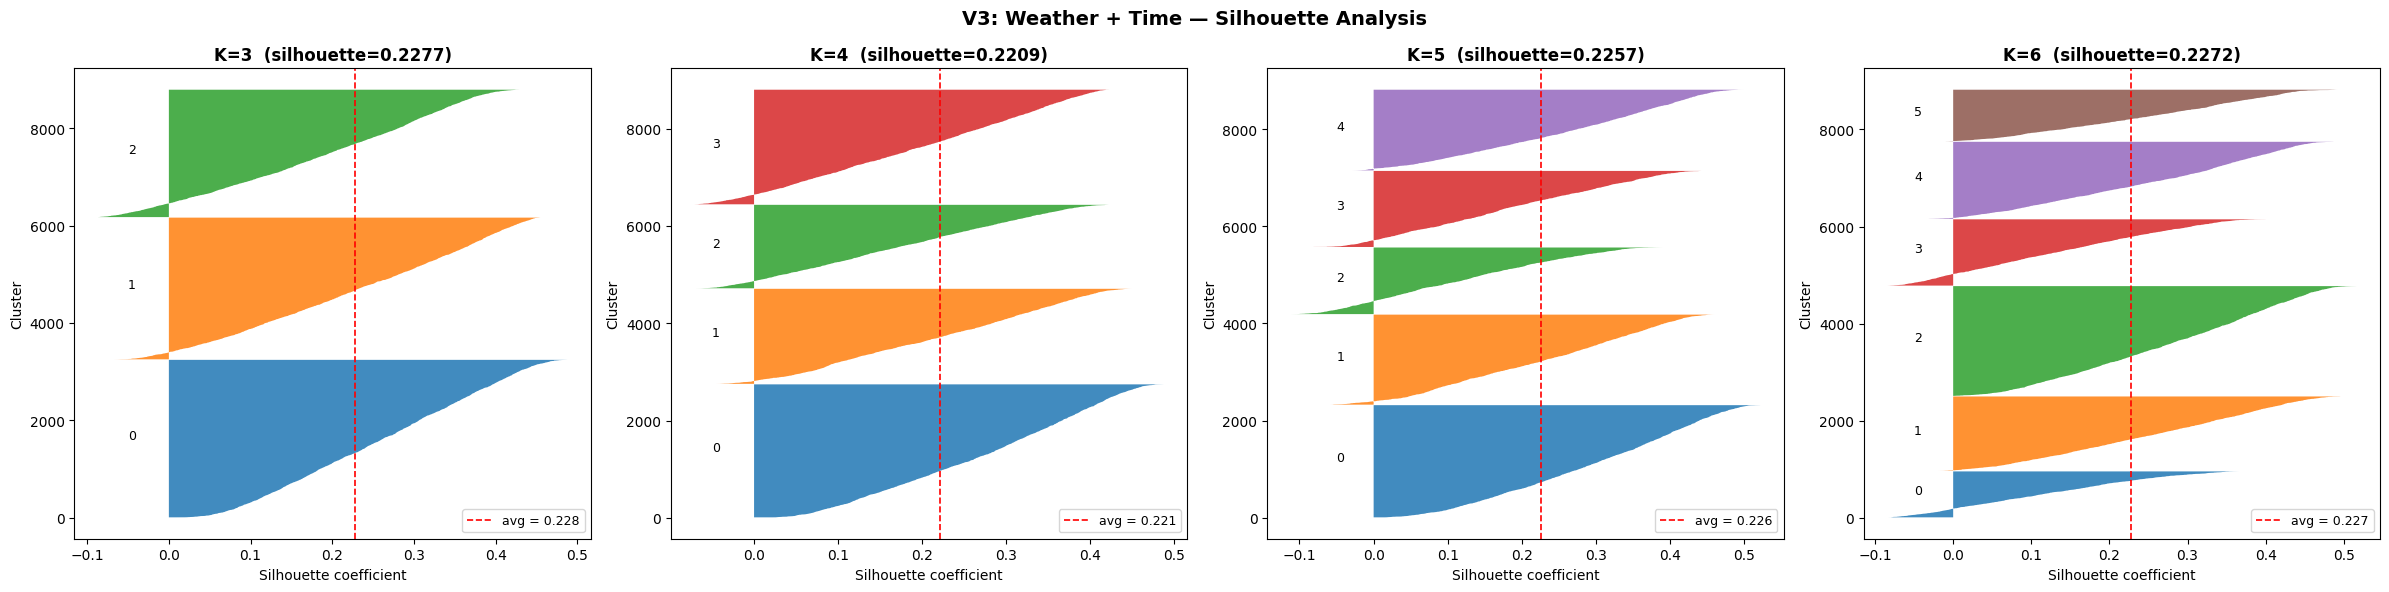

In [46]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle('V3: Weather + Time — Silhouette Analysis', fontsize=14, fontweight='bold')

for ax, k in zip(axes, K_COMPARE):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_v3)
    plot_silhouette(X_v3, km.labels_, k, ax)
    sil = silhouette_score(X_v3, km.labels_)
    ax.set_title(f'K={k}  (silhouette={sil:.4f})', fontweight='bold')

plt.tight_layout()
plt.savefig("visuals/task3_v3_silhouette_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.6 K Comparison: PCA Visualization

Each subplot shows the 2D PCA projection for a given (version, K) combination. Red X marks are centroids.

### 3.6.1 V2: Weather Only — PCA (K = 3, 4, 5, 6)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


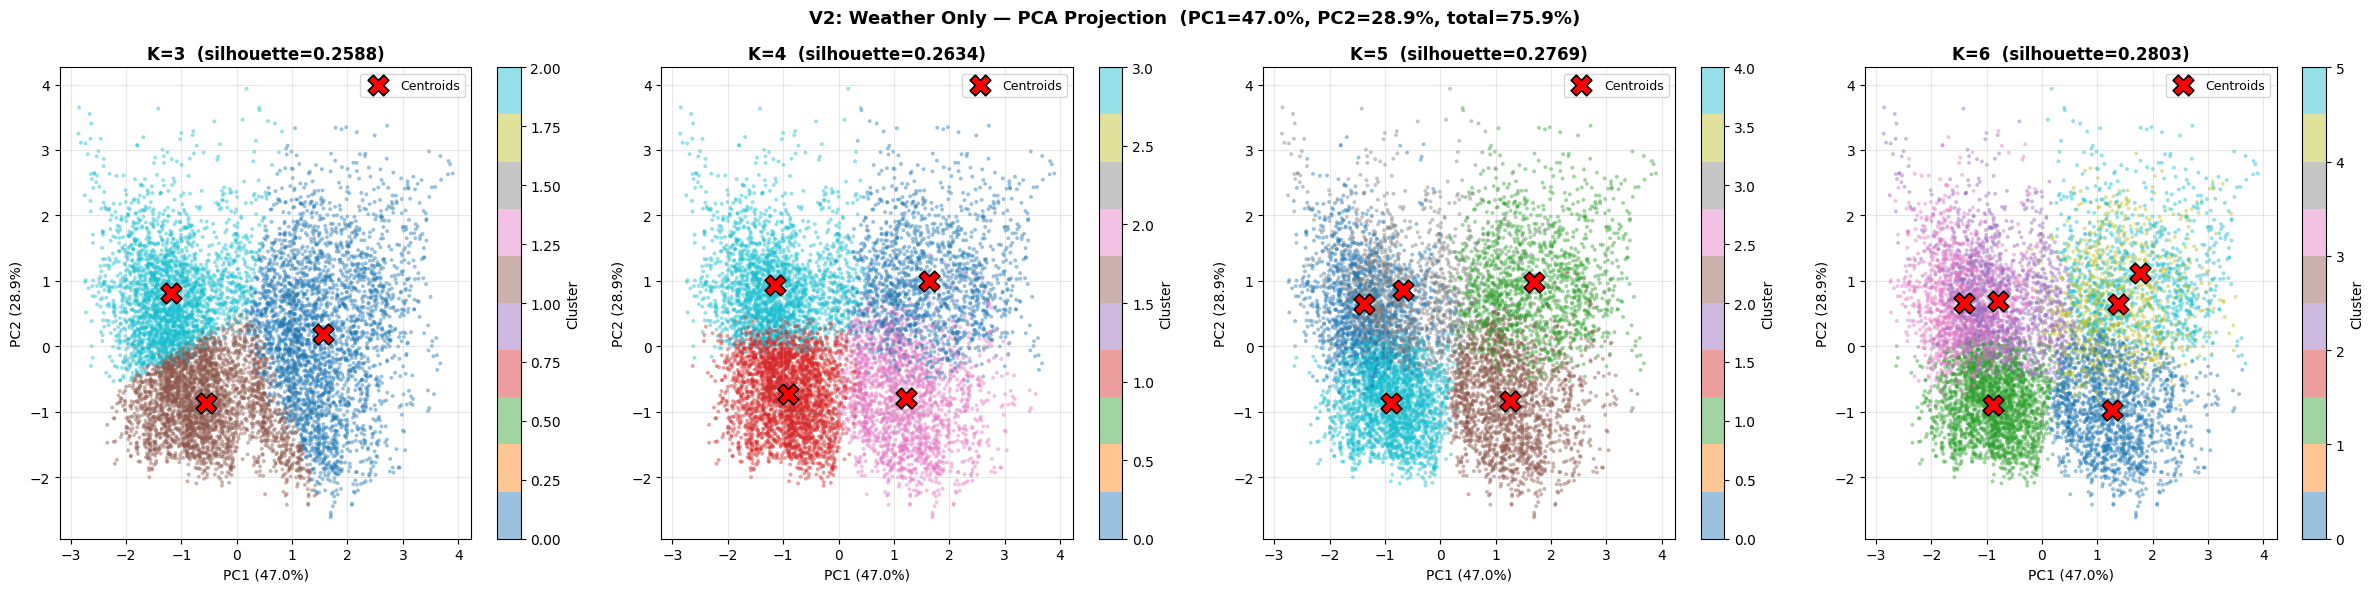

In [47]:
pca_v2 = PCA(n_components=2).fit(X_v2)
X_pca_v2 = pca_v2.transform(X_v2)
var_v2 = pca_v2.explained_variance_ratio_

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle(
    f'V2: Weather Only — PCA Projection  (PC1={var_v2[0]:.1%}, PC2={var_v2[1]:.1%}, total={var_v2.sum():.1%})',
    fontsize=13, fontweight='bold'
)

for ax, k in zip(axes, K_COMPARE):
    labels = models_v2[k].labels_
    centers_pca = pca_v2.transform(models_v2[k].cluster_centers_)
    sil = silhouette_score(X_v2, labels)

    sc = ax.scatter(X_pca_v2[:, 0], X_pca_v2[:, 1],
                    c=labels, cmap='tab10', s=8, alpha=0.45, edgecolors='none')
    ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
               c='red', marker='X', s=220, edgecolors='black', linewidths=1.2,
               label='Centroids', zorder=5)
    ax.set_title(f'K={k}  (silhouette={sil:.4f})', fontweight='bold')
    ax.set_xlabel(f'PC1 ({var_v2[0]:.1%})')
    ax.set_ylabel(f'PC2 ({var_v2[1]:.1%})')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label='Cluster')

plt.tight_layout()
plt.savefig("visuals/task3_v2_pca_projection.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.6.2 V3: Weather + Time — PCA (K = 3, 4, 5, 6)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


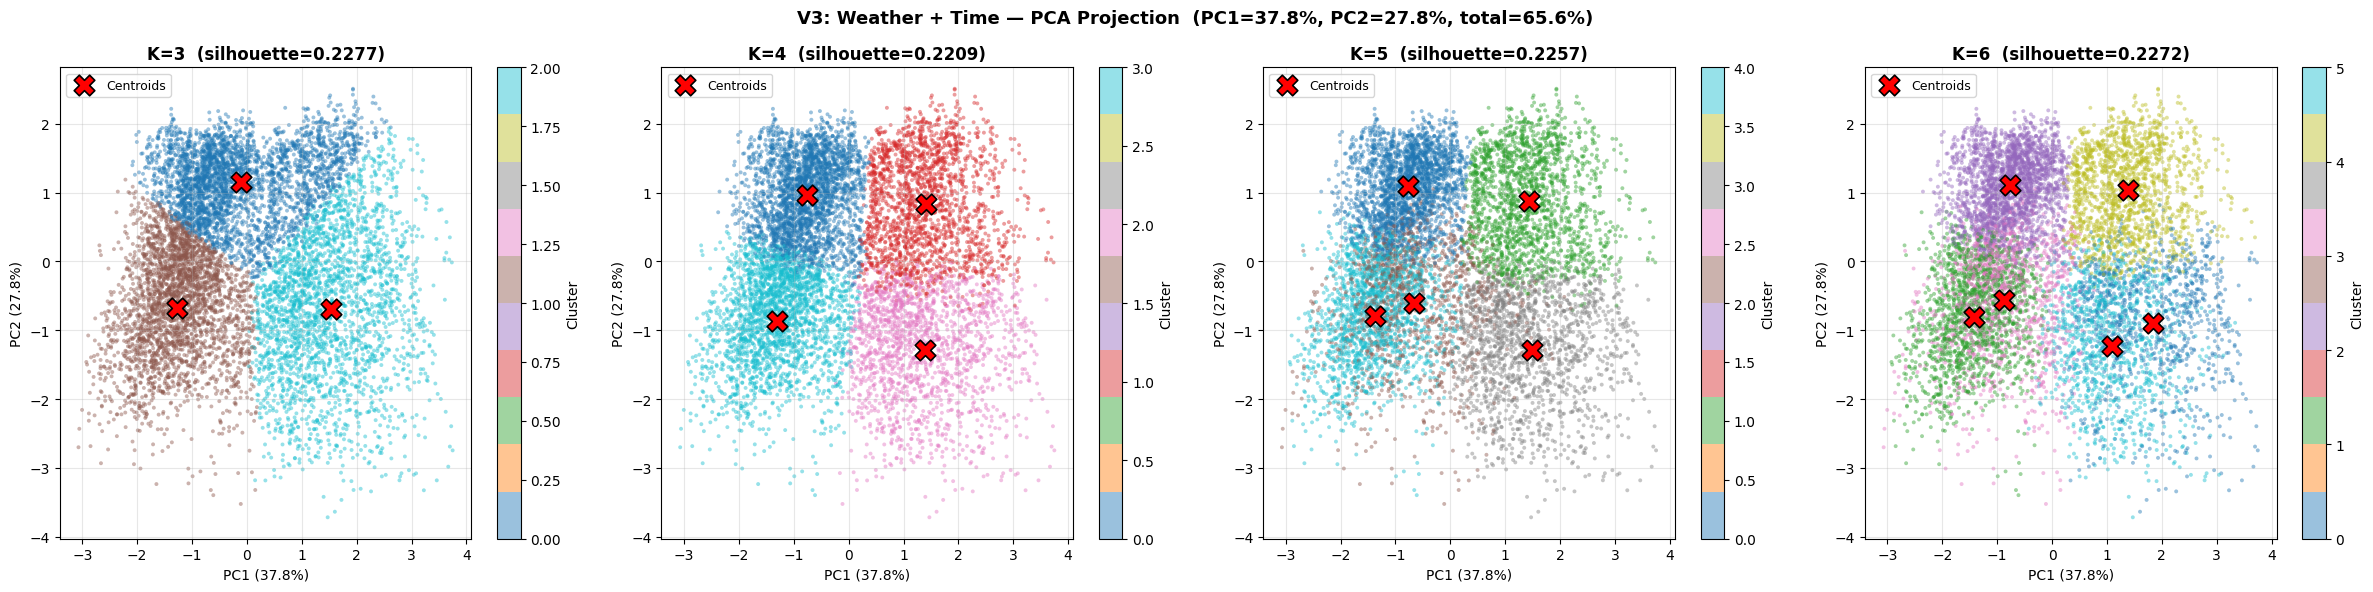

In [48]:
pca_v3 = PCA(n_components=2).fit(X_v3)
X_pca_v3 = pca_v3.transform(X_v3)
var_v3 = pca_v3.explained_variance_ratio_

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle(
    f'V3: Weather + Time — PCA Projection  (PC1={var_v3[0]:.1%}, PC2={var_v3[1]:.1%}, total={var_v3.sum():.1%})',
    fontsize=13, fontweight='bold'
)

for ax, k in zip(axes, K_COMPARE):
    labels = models_v3[k].labels_
    centers_pca = pca_v3.transform(models_v3[k].cluster_centers_)
    sil = silhouette_score(X_v3, labels)

    sc = ax.scatter(X_pca_v3[:, 0], X_pca_v3[:, 1],
                    c=labels, cmap='tab10', s=8, alpha=0.45, edgecolors='none')
    ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
               c='red', marker='X', s=220, edgecolors='black', linewidths=1.2,
               label='Centroids', zorder=5)
    ax.set_title(f'K={k}  (silhouette={sil:.4f})', fontweight='bold')
    ax.set_xlabel(f'PC1 ({var_v3[0]:.1%})')
    ax.set_ylabel(f'PC2 ({var_v3[1]:.1%})')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label='Cluster')

plt.tight_layout()
plt.savefig("visuals/task3_v3_pca_projection.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.6.3 PCA Loadings Heatmap

Loadings show how much each original feature contributes to PC1 and PC2, helping us understand what each principal component actually represents.

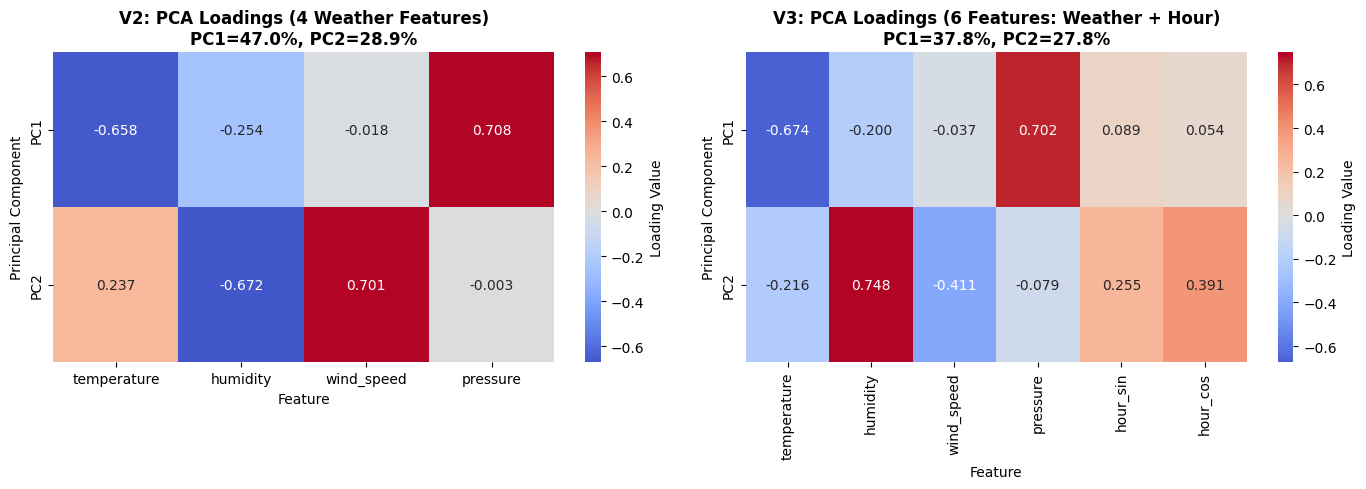

In [49]:
# Build loadings DataFrames from the already-fitted PCA objects
loadings_v2 = pd.DataFrame(
    pca_v2.components_.T,
    index=FEATURES_V2,
    columns=[f'PC{i+1}' for i in range(pca_v2.n_components_)]
)

loadings_v3 = pd.DataFrame(
    pca_v3.components_.T,
    index=FEATURES_V3,
    columns=[f'PC{i+1}' for i in range(pca_v3.n_components_)]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(loadings_v2.T, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=axes[0], cbar_kws={'label': 'Loading Value'})
axes[0].set_title(
    f'V2: PCA Loadings (4 Weather Features)\n'
    f'PC1={pca_v2.explained_variance_ratio_[0]:.1%}, PC2={pca_v2.explained_variance_ratio_[1]:.1%}',
    fontsize=12, fontweight='bold'
)
axes[0].set_ylabel('Principal Component')
axes[0].set_xlabel('Feature')

sns.heatmap(loadings_v3.T, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=axes[1], cbar_kws={'label': 'Loading Value'})
axes[1].set_title(
    f'V3: PCA Loadings (6 Features: Weather + Hour)\n'
    f'PC1={pca_v3.explained_variance_ratio_[0]:.1%}, PC2={pca_v3.explained_variance_ratio_[1]:.1%}',
    fontsize=12, fontweight='bold'
)
axes[1].set_ylabel('Principal Component')
axes[1].set_xlabel('Feature')

plt.tight_layout()
plt.savefig("visuals/task3_pca_loadings.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.7 Choosing the Final Model: V2, K = 4

### **Step 1 - Choosing K**
K is selected purely on unsupervised metrics — silhouette score, inertia elbow, and PCA
visual clarity — with no reference to feature set or label information.

| K | V2 Silhouette | V2 WR Range | V3 Silhouette | V3 WR Range | Notes |
|---|---|---|---|---|---|
| 3 | 0.2588 | 15.16% | 0.2277 | 18.62% | Elbow point; baseline |
| **4** | **0.2634** | **22.29%** | 0.2209 | 18.06% | ← **selected** |
| 5 | 0.2769 | 26.98% | 0.2257 | 22.07% | Higher metrics; PCA overlap |
| 6 | 0.2803 | 48.52% | 0.2272 | 47.74% | Best metrics; heavy PCA overlap |

**K = 3** is the elbow point — the steepest inertia drop occurs here and PCA clusters
are the most visually separable. However, a warning rate range of only 15% means the
three clusters do not sufficiently distinguish between different air quality risk levels.

**K = 5 and K = 6** score higher on both silhouette and warning rate range, but PCA
projections show that cluster boundaries become increasingly unclear — points from
different clusters overlap substantially, making interpretation unreliable. K = 6 does
isolate a meaningful low-risk cluster (WR ~40%), but two of the six centroids sit within
the same dense region in PCA space, indicating the extra clusters subdivide an already-
compact group without revealing genuinely new structure.

**K = 4** strikes the best balance between statistical quality and visual
interpretability. It improves over K = 3 on both silhouette (0.2588 → 0.2634) and
warning rate range (15% → 22%), while maintaining clear and well-separated cluster
boundaries in PCA projection — which K = 5 and K = 6 fail to preserve.

### **Step 2 — Choosing V2 over V3 (at K = 4)**

With K = 4 fixed, V2 and V3 are compared on two levels:

#### **Level 1 — Clustering metrics** (Sections 3.4–3.6) 
Across all K values, V3 consistently produces lower silhouette scores and weaker warning rate separation compared to V2:

| K | V2 Silhouette | V3 Silhouette | V2 WR Range | V3 WR Range |
|---|---|---|---|---|
| 3 | 0.2588 | 0.2277 | 15.16% | 18.62% |
| 4 | 0.2634 | 0.2209 | 22.29% | 18.06% |
| 5 | 0.2769 | 0.2257 | 26.98% | 22.07% |
| 6 | 0.2803 | 0.2272 | 48.52% | 47.74% |

The cyclical hour encodings (`hour_sin` / `hour_cos`) do not capture additional
structure beyond what the weather features already encode — they introduce noise into
the feature space, dilute the weather signal, and produce weaker, more overlapping
clusters. V2 is not only simpler but demonstrably better on every clustering metric.

#### **Level 2 — Supervised validation**

Here we apply the supervised models from Task 2 as an **independent judge**: if
a model trained on labelled data — without knowledge of cluster assignments — predicts
warning rates that closely match each cluster's actual warning rate, the cluster boundaries
are genuinely capturing structure relevant to `is_warning`.

**Approach:**
1. With K = 4 fixed, retrain Task 2's Logistic Regression and SVM (same features, config, and split)
2. For each of the four clusters in V2 and V3, apply the trained model to the test-set points inside that cluster
3. Compare the model's **predicted warning rate** against the **actual warning rate** per cluster
4. The feature set with lower Mean Absolute Difference (MAD) produces clusters more aligned with the supervised decision boundary — and is therefore the stronger choice

**1) Setup: recover `hour` and define Task 2 features**

In [50]:
RANDOM_STATE = 42
OPTIMAL_K    = 4  # defined here for validation; reused in Section 3.9

# Assign cluster labels using the optimal K
# models_v2 / models_v3 were fitted in Section 3.4
df['Cluster_v2'] = models_v2[OPTIMAL_K].labels_
df['Cluster_v3'] = models_v3[OPTIMAL_K].labels_

# 'hour' was dropped during cyclical encoding in Section 3.1 — recover from timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour

TASK2_FEATURES = ['temperature', 'humidity', 'wind_speed', 'pressure', 'hour', 'day_of_week']
TARGET = 'is_warning'

missing = [f for f in TASK2_FEATURES if f not in df.columns]
print("Task 2 features :", TASK2_FEATURES)
print(f"Missing from df : {missing if missing else 'None — all features available ✓'}")

Task 2 features : ['temperature', 'humidity', 'wind_speed', 'pressure', 'hour', 'day_of_week']
Missing from df : None — all features available ✓


**2) Season-aware chronological split (same as Task 2)**

Replicate the exact 70/30 season-aware split used in Task 2.

**Note:** The original df index is preserved (no `reset_index`) so that cluster labels in `df['Cluster_v2']` and `df['Cluster_v3']` can be looked up by index for test-set filtering in Step 4.

In [51]:
def _month_to_season(month):
    if month in [1, 2, 3]:   return "Spring"
    elif month in [4, 5, 6]: return "Summer"
    elif month in [7, 8, 9]: return "Autumn"
    else:                     return "Winter"

df['month']  = df['timestamp'].dt.month
df['season'] = df['month'].apply(_month_to_season)

train_parts, test_parts = [], []
for season in ["Spring", "Summer", "Autumn", "Winter"]:
    s   = df[df['season'] == season].sort_values('timestamp')
    cut = int(len(s) * 0.7)
    train_parts.append(s.iloc[:cut])
    test_parts.append(s.iloc[cut:])

# Preserve original df index — needed to look up cluster labels in Step 4
train_df_val = pd.concat(train_parts).sort_values('timestamp')
test_df_val  = pd.concat(test_parts).sort_values('timestamp')

X_train_val = train_df_val[TASK2_FEATURES]
y_train_val = train_df_val[TARGET]
X_test_val  = test_df_val[TASK2_FEATURES]
y_test_val  = test_df_val[TARGET]

print(f"Train : {len(train_df_val):,} samples  |  warning rate : {y_train_val.mean():.3f}")
print(f"Test  : {len(test_df_val):,} samples  |  warning rate : {y_test_val.mean():.3f}")

Train : 6,130 samples  |  warning rate : 0.752
Test  : 2,630 samples  |  warning rate : 0.799


**3) Retrain Task 2 models (same configuration)**

| Model | Config |
|---|---|
| Logistic Regression | `class_weight='balanced'`, `max_iter=5000`, `StandardScaler` |
| SVM RBF | `C=1`, `gamma='scale'`, `class_weight='balanced'`, `StandardScaler` |

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

lr_val = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=5000, class_weight='balanced',
                                  random_state=RANDOM_STATE))
])
svm_val = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced',
                   probability=True, random_state=RANDOM_STATE))
])

lr_val.fit(X_train_val, y_train_val)
svm_val.fit(X_train_val, y_train_val)

print(f"{'Model':<22} {'Test Accuracy':>14} {'Test F1':>10}")
print('─' * 50)
for name, model in [('Logistic Regression', lr_val), ('SVM RBF', svm_val)]:
    preds = model.predict(X_test_val)
    print(f"{name:<22} {accuracy_score(y_test_val, preds):>14.3f}"
          f" {f1_score(y_test_val, preds):>10.3f}")

Model                   Test Accuracy    Test F1
──────────────────────────────────────────────────
Logistic Regression             0.678      0.774
SVM RBF                         0.711      0.810


**4) Predict `is_warning` per cluster (test set only)**

For each cluster, we take only the **test set points** that fall inside that cluster, then apply
the trained model to compute the predicted warning rate.

Using the test set avoids inflated agreement on training data — the model has never seen these
points during training, so any alignment between predicted and actual warning rates is genuine.

In [53]:
val_rows = []

for clf_name, model in [('Logistic Regression', lr_val), ('SVM RBF', svm_val)]:
    for ver_label, cluster_col in [('V2 — Weather Only',   'Cluster_v2'),
                                    ('V3 — Weather + Time', 'Cluster_v3')]:

        # Look up cluster label for each test-set row using the preserved df index
        test_clusters = df.loc[test_df_val.index, cluster_col]

        for c in sorted(df[cluster_col].unique()):
            mask     = test_clusters == c                       # test rows in cluster c
            X_c      = test_df_val.loc[mask.index[mask], TASK2_FEATURES]
            y_true   = test_df_val.loc[mask.index[mask], TARGET]
            y_pred   = model.predict(X_c)

            actual_wr = y_true.mean() * 100
            pred_wr   = y_pred.mean() * 100

            val_rows.append({
                'Classifier':       clf_name,
                'Feature Set':      ver_label,
                'Cluster':          int(c),
                'N (test)':         int(mask.sum()),
                'Actual WR%':       round(actual_wr, 1),
                'Predicted WR%':    round(pred_wr,   1),
                'Δ (pred−actual)':  round(pred_wr - actual_wr, 1),
            })

val_df = pd.DataFrame(val_rows)
print("Predicted vs actual warning rate per cluster (test set only):")
display(val_df)

Predicted vs actual warning rate per cluster (test set only):


,Classifier,Feature Set,Cluster,N (test),Actual WR%,Predicted WR%,Δ (pred−actual)
0,Logistic Regression,V2 — Weather Only,0,463,64.1,35.6,-28.5
1,Logistic Regression,V2 — Weather Only,1,863,87.5,93.0,5.6
2,Logistic Regression,V2 — Weather Only,2,609,89.8,36.8,-53.0
3,Logistic Regression,V2 — Weather Only,3,695,72.2,64.6,-7.6
4,Logistic Regression,V3 — Weather + Time,0,844,81.4,82.8,1.4
5,Logistic Regression,V3 — Weather + Time,1,566,87.8,32.7,-55.1
6,Logistic Regression,V3 — Weather + Time,2,493,68.0,40.6,-27.4
7,Logistic Regression,V3 — Weather + Time,3,727,80.1,76.6,-3.4
8,SVM RBF,V2 — Weather Only,0,463,64.1,42.8,-21.4
9,SVM RBF,V2 — Weather Only,1,863,87.5,87.3,-0.2


**5) Visualize alignment**

Bars that are close in height → the supervised model agrees with the cluster's actual warning
composition → the cluster boundary is meaningful for the prediction task.

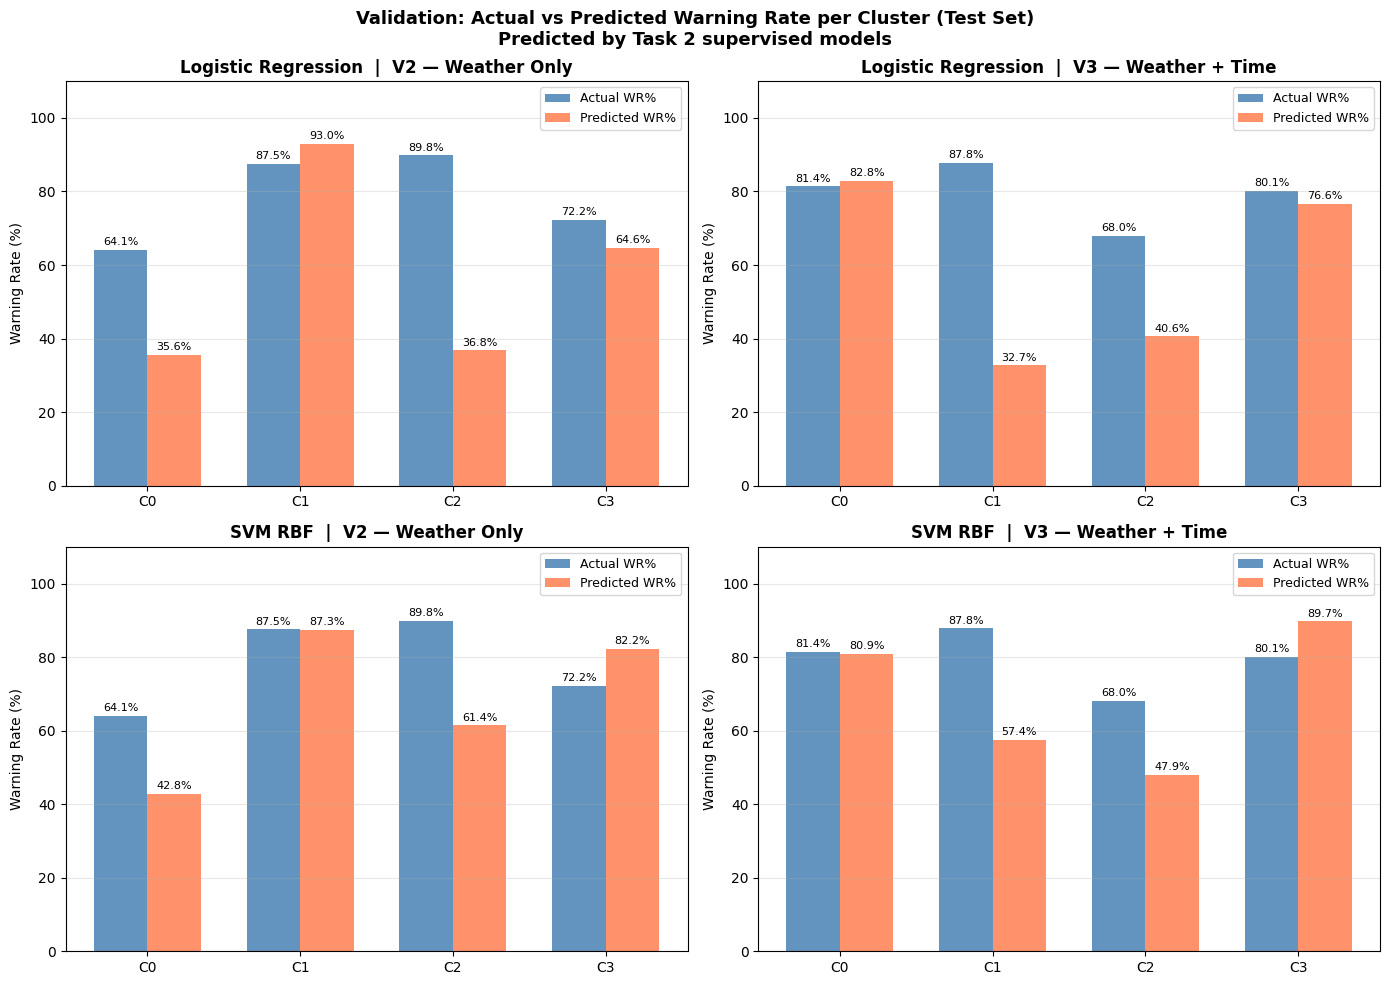

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Validation: Actual vs Predicted Warning Rate per Cluster (Test Set)\n'
    'Predicted by Task 2 supervised models',
    fontsize=13, fontweight='bold'
)

x = np.arange(4)
w = 0.35

for row, clf_name in enumerate(['Logistic Regression', 'SVM RBF']):
    for col, ver_label in enumerate(['V2 — Weather Only', 'V3 — Weather + Time']):
        ax  = axes[row, col]
        sub = val_df[(val_df['Classifier'] == clf_name) &
                     (val_df['Feature Set'] == ver_label)].sort_values('Cluster')

        b1 = ax.bar(x - w/2, sub['Actual WR%'],    w,
                    label='Actual WR%',    color='steelblue', alpha=0.85)
        b2 = ax.bar(x + w/2, sub['Predicted WR%'], w,
                    label='Predicted WR%', color='coral',     alpha=0.85)

        ax.set_xticks(x)
        ax.set_xticklabels([f'C{c}' for c in sub['Cluster']])
        ax.set_ylim(0, 110)
        ax.set_ylabel('Warning Rate (%)')
        ax.set_title(f'{clf_name}  |  {ver_label}', fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        ax.bar_label(b1, fmt='%.1f%%', padding=2, fontsize=8)
        ax.bar_label(b2, fmt='%.1f%%', padding=2, fontsize=8)

plt.tight_layout()
plt.savefig("visuals/task3_validation_actual_vs_predicted_wr.png", dpi=300, bbox_inches="tight")
plt.show()

**6) Quantify alignment: V2 vs V3**

**Mean Absolute Difference (MAD)** between actual and predicted warning rate across clusters:
- Lower MAD → model and clustering agree more closely → feature set produces more meaningful clusters

**Warning Rate Range** (max − min across clusters):
- Higher range → clusters are more separated in terms of air quality risk

In [55]:
alignment = val_df.copy()
alignment['AbsDiff'] = alignment['Δ (pred−actual)'].abs()

summary = (
    alignment
    .groupby(['Classifier', 'Feature Set'])
    .agg(
        MAD_pct          = ('AbsDiff',       'mean'),
        WR_Range_Actual  = ('Actual WR%',    lambda x: x.max() - x.min()),
        WR_Range_Pred    = ('Predicted WR%', lambda x: x.max() - x.min()),
    )
    .round(2)
)

print("Alignment summary:")
display(summary)

print()
print('─' * 65)
for clf in ['Logistic Regression', 'SVM RBF']:
    v2 = summary.loc[(clf, 'V2 — Weather Only'),   'MAD_pct']
    v3 = summary.loc[(clf, 'V3 — Weather + Time'), 'MAD_pct']
    better = 'V2 (Weather Only)' if v2 <= v3 else 'V3 (Weather + Time)'
    print(f"  {clf}: {better} aligns better  "
          f"(V2 MAD = {v2:.2f}%  |  V3 MAD = {v3:.2f}%)")

Alignment summary:


MAD_pct  WR_Range_Actual  \
Classifier          Feature Set                                     
Logistic Regression V2 — Weather Only      23.68             25.7   
                    V3 — Weather + Time    21.82             19.8   
SVM RBF             V2 — Weather Only      14.98             25.7   
                    V3 — Weather + Time    15.15             19.8   

                                         WR_Range_Pred  
Classifier          Feature Set                         
Logistic Regression V2 — Weather Only             57.4  
                    V3 — Weather + Time           50.1  
SVM RBF             V2 — Weather Only             44.5  
                    V3 — Weather + Time           41.8


─────────────────────────────────────────────────────────────────
  Logistic Regression: V3 (Weather + Time) aligns better  (V2 MAD = 23.68%  |  V3 MAD = 21.82%)
  SVM RBF: V2 (Weather Only) aligns better  (V2 MAD = 14.98%  |  V3 MAD = 15.15%)


The two classifiers do not fully agree: Logistic Regression marginally favours V3
(MAD 21.82 vs 23.68, a difference of 1.86 pp), while SVM marginally favours V2
(MAD 14.98 vs 15.15, a difference of 0.17 pp). However, two model-independent
observations consistently point to V2:

- **Primary judge — SVM**: Task 2 established that SVM RBF outperforms Logistic
  Regression on this dataset (higher F1 and ROC-AUC, better seasonal robustness,
  stronger performance on pressure and temperature — the dominant features). When the
  more reliable classifier is used as the judge, V2 produces lower MAD. The LR
  advantage for V3 is also small (< 2 pp) and likely reflects LR's known sensitivity
  to feature scale and its weaker fit on this dataset rather than a genuine V3
  superiority.

- **Warning rate separation — both classifiers agree**: Regardless of which classifier
  is used, V2 clusters have a consistently wider actual warning rate range (25.7%) than
  V3 clusters (19.8%). This means V2 creates four groups that are more distinctly
  separated by air quality risk level — a property that holds independent of any model
  assumption. The predicted warning rate range also favours V2 under both classifiers
  (57.4% vs 50.1% for LR; 44.5% vs 41.8% for SVM).

> **Final selection: V2, K = 4** — four weather features (temperature, humidity, wind
> speed, pressure), four clusters. K = 4 selected on clustering metrics (Step 1);
> V2 selected over V3 on both clustering metrics and supervised validation (Step 2).

## 3.8 Final Model: V2, K=4

In [56]:
OPTIMAL_K = 4
km_v2 = models_v2[OPTIMAL_K]
km_v3 = models_v3[OPTIMAL_K]

df['Cluster_v2'] = km_v2.labels_
df['Cluster_v3'] = km_v3.labels_

sil_v2 = silhouette_score(X_v2, km_v2.labels_)
sil_v3 = silhouette_score(X_v3, km_v3.labels_)

print(f'  Final Model Metrics (K={OPTIMAL_K})')
print(f'  V2 — Inertia: {km_v2.inertia_:>10,.2f}   Silhouette: {sil_v2:.4f}')
print(f'  V3 — Inertia: {km_v3.inertia_:>10,.2f}   Silhouette: {sil_v3:.4f}')
print()
print(f'  V2 cluster sizes: {dict(zip(*np.unique(km_v2.labels_, return_counts=True)))}')
print(f'  V3 cluster sizes: {dict(zip(*np.unique(km_v3.labels_, return_counts=True)))}')

print(f'\n  {"─"*50}')
print(f'  Final Model Selected: V2, K = {OPTIMAL_K}')
print(f'  {"─"*50}')
r_final = df.groupby('Cluster_v2')['is_warning'].mean().mul(100)
print(f'  Inertia:              {km_v2.inertia_:>12,.2f}')
print(f'  Silhouette:           {sil_v2:>12.4f}')
print(f'  Warning rate min:     {r_final.min():>11.2f}%')
print(f'  Warning rate max:     {r_final.max():>11.2f}%')
print(f'  Warning rate range:   {r_final.max()-r_final.min():>9.2f}%')
print()
print(f'  Cluster breakdown:')
for cluster, count in zip(*np.unique(km_v2.labels_, return_counts=True)):
    pct = count / len(df) * 100
    print(f'    Cluster {cluster}: {count:>4} points ({pct:>5.1f}%)   WR: {r_final[cluster]:.2f}%')

  Final Model Metrics (K=4)
  V2 — Inertia:  15,224.65   Silhouette: 0.2634
  V3 — Inertia:  22,295.40   Silhouette: 0.2209

  V2 cluster sizes: {np.int32(0): np.int64(1643), np.int32(1): np.int64(2855), np.int32(2): np.int64(2047), np.int32(3): np.int64(2215)}
  V3 cluster sizes: {np.int32(0): np.int64(2734), np.int32(1): np.int64(1954), np.int32(2): np.int64(1716), np.int32(3): np.int64(2356)}

  ──────────────────────────────────────────────────
  Final Model Selected: V2, K = 4
  ──────────────────────────────────────────────────
  Inertia:                 15,224.65
  Silhouette:                 0.2634
  Warning rate min:           61.11%
  Warning rate max:           83.40%
  Warning rate range:       22.29%

  Cluster breakdown:
    Cluster 0: 1643 points ( 18.8%)   WR: 61.11%
    Cluster 1: 2855 points ( 32.6%)   WR: 83.40%
    Cluster 2: 2047 points ( 23.4%)   WR: 78.11%
    Cluster 3: 2215 points ( 25.3%)   WR: 77.88%


In [57]:
profile_cols = ['temperature', 'humidity', 'wind_speed', 'pressure']

profile_v2 = df.groupby('Cluster_v2')[profile_cols].mean().round(2)
profile_v2['count']        = df['Cluster_v2'].value_counts().sort_index()
profile_v2['warning_rate'] = (df.groupby('Cluster_v2')['is_warning'].mean() * 100).round(1)
profile_v2['avg_aqi']      = df.groupby('Cluster_v2')['aqi'].mean().round(1)
profile_v2['avg_pm25']     = df.groupby('Cluster_v2')['pm25'].mean().round(1)

print(f'V2 Cluster Profiles (K={OPTIMAL_K}):')
print(profile_v2.to_string())

V2 Cluster Profiles (K=4):
            temperature  humidity  wind_speed  pressure  count  warning_rate  avg_aqi  avg_pm25
Cluster_v2                                                                                     
0                 19.95     58.38        2.82   1017.58   1643          61.1    120.2      42.2
1                 26.56     89.45        1.67   1004.54   2855          83.4    130.5      56.2
2                 18.05     85.62        1.93   1015.52   2047          78.1    135.0      68.4
3                 28.78     76.30        3.48   1002.98   2215          77.9    128.5      38.8


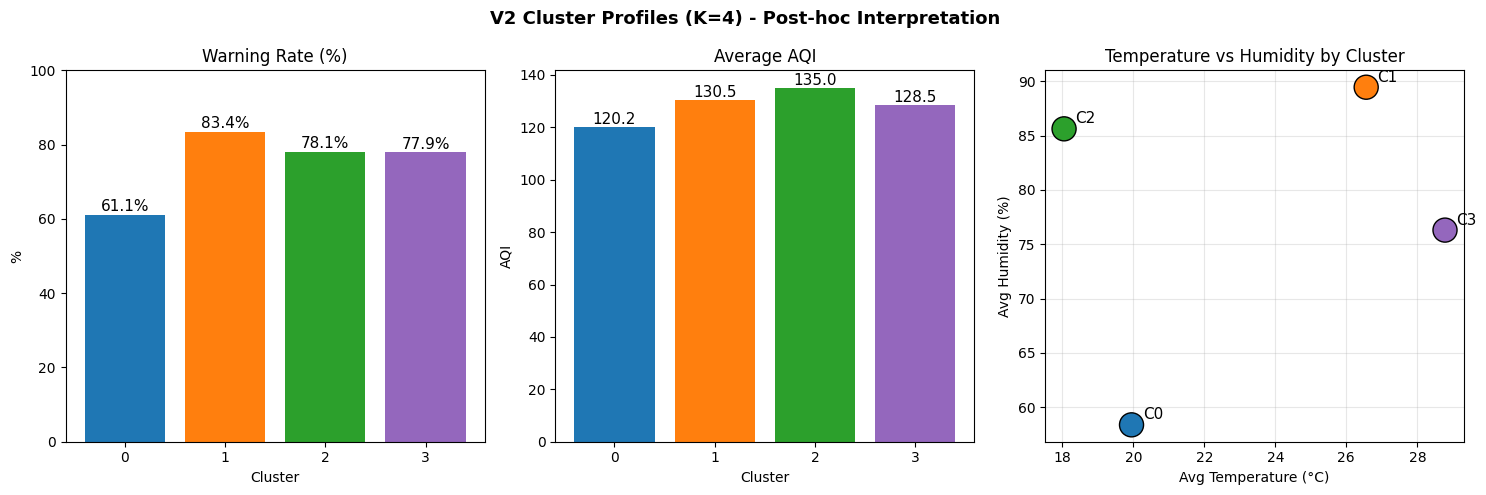

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('V2 Cluster Profiles (K=4) - Post-hoc Interpretation', fontsize=13, fontweight='bold')

clusters = profile_v2.index
colors = plt.cm.tab10(np.linspace(0, 0.4, OPTIMAL_K))

# Warning rate
axes[0].bar(clusters, profile_v2['warning_rate'], color=colors)
axes[0].set_title('Warning Rate (%)')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('%')
axes[0].set_ylim(0, 100)
axes[0].set_xticks(clusters)
for i, v in enumerate(profile_v2['warning_rate']):
    axes[0].text(i, v + 1, f'{v}%', ha='center', fontsize=11)

# Average AQI
axes[1].bar(clusters, profile_v2['avg_aqi'], color=colors)
axes[1].set_title('Average AQI')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('AQI')
axes[1].set_xticks(clusters)
for i, v in enumerate(profile_v2['avg_aqi']):
    axes[1].text(i, v + 1, f'{v}', ha='center', fontsize=11)

# Average Temperature vs Humidity scatter
axes[2].scatter(
    profile_v2['temperature'], profile_v2['humidity'],
    c=colors, s=300, edgecolors='black', zorder=5
)
for i, row in profile_v2.iterrows():
    axes[2].annotate(f'C{i}', (row['temperature'], row['humidity']),
                     textcoords='offset points', xytext=(8, 4), fontsize=11)
axes[2].set_title('Temperature vs Humidity by Cluster')
axes[2].set_xlabel('Avg Temperature (°C)')
axes[2].set_ylabel('Avg Humidity (%)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("visuals/task3_v2_k4_cluster_profiles.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.9 Summary

In [59]:
summary = pd.DataFrame({
    'Metric': ['Features used', 'Optimal K', 'Inertia (loss)',
               'Silhouette score', 'PCA variance explained (PC1+PC2)'],
    'V2 — Weather Only (final)': [
        ', '.join(FEATURES_V2), OPTIMAL_K,
        f'{km_v2.inertia_:,.1f}', f'{sil_v2:.4f}',
        f'{pca_v2.explained_variance_ratio_.sum():.2%}'
    ],
    'V3 — Weather + Time': [
        ', '.join(FEATURES_V3), OPTIMAL_K,
        f'{km_v3.inertia_:,.1f}', f'{sil_v3:.4f}',
        f'{pca_v3.explained_variance_ratio_.sum():.2%}'
    ]
})

print(summary.to_string(index=False))
print()
print('V2 (K=4) is selected as the final model.')
print('Weather features alone (temperature, humidity, wind speed, pressure)')
print('produce stronger and more interpretable clusters than adding time')
print('encodings — V2 outperforms V3 on silhouette, warning rate separation,')
print('and PCA visual clarity across all tested values of K.')

                          Metric                   V2 — Weather Only (final)                                             V3 — Weather + Time
                   Features used temperature, humidity, wind_speed, pressure temperature, humidity, wind_speed, pressure, hour_sin, hour_cos
                       Optimal K                                           4                                                               4
                  Inertia (loss)                                    15,224.6                                                        22,295.4
                Silhouette score                                      0.2634                                                          0.2209
PCA variance explained (PC1+PC2)                                      75.90%                                                          65.59%

V2 (K=4) is selected as the final model.
Weather features alone (temperature, humidity, wind speed, pressure)
produce stronger and more interpretable clu